In [1]:
import numpy as np

def evt_empirical_bayes_max_at_k(batch_scores, target_k):
    """
    Estimates the expected max@k for a batch of prompts using EVT and Empirical Bayes.
    
    Args:
        batch_scores: np.ndarray of shape (M, n) 
                      M = number of prompts in the batch
                      n = number of completions generated per prompt
        target_k: int, the target extrapolation budget (e.g., 1000)
        
    Returns:
        expected_max_k: np.ndarray of shape (M,) containing the max@k estimates
    """
    M, n = batch_scores.shape
    
    # 1. Local Maximums
    M_n = np.max(batch_scores, axis=1)
    
    # 2. Global Batch Statistics
    mu_global = np.mean(M_n)
    
    # Variance of the maximums across different prompts (Signal)
    var_maxes = np.var(M_n, ddof=1) 
    
    # Average variance of completions within the same prompt (Noise)
    var_within = np.mean(np.var(batch_scores, axis=1, ddof=1)) 
    
    # Global Gumbel scale parameter (beta)
    beta_hat = (np.sqrt(6) / np.pi) * np.sqrt(var_within)
    
    # 3. James-Stein Shrinkage (Empirical Bayes)
    # Clamp weight to 0 to prevent negative shrinkage if noise > signal
    w = max(0.0, 1.0 - (var_within / var_maxes))
    mu_local = w * M_n + (1 - w) * mu_global
    
    # 4. EVT Extrapolation
    euler_gamma = np.euler_gamma # ~0.5772
    expected_max_k = mu_local + beta_hat * np.log(target_k / n) + beta_hat * euler_gamma
    
    return expected_max_k

# ==========================================
# ADVERSARIAL EVALUATION ENVIRONMENT
# ==========================================

np.random.seed(42)

M_per_type = 1000  # Number of prompts per cluster
n_gen = 8          # Budget generated during training
k_target = 8    # Budget we want to extrapolate to

# 1. Type A: "Easy & Deterministic" (Breaks Homoscedasticity)
# High base score, very low variance
scores_A_n = np.random.normal(loc=85, scale=1.0, size=(M_per_type, n_gen))
scores_A_k = np.random.normal(loc=85, scale=1.0, size=(M_per_type, k_target))

# 2. Type B: "Hard & Noisy" (Breaks Unimodal Prior)
# Low base score, very high variance
scores_B_n = np.random.normal(loc=30, scale=15.0, size=(M_per_type, n_gen))
scores_B_k = np.random.normal(loc=30, scale=15.0, size=(M_per_type, k_target))

# 3. Type C: "Reward Hacked" (Breaks Gumbel / Exponential Tail)
# Pareto distribution with infinite variance (shape=1.5)
scores_C_n = np.random.pareto(a=1.5, size=(M_per_type, n_gen)) * 10 + 40
scores_C_k = np.random.pareto(a=1.5, size=(M_per_type, k_target)) * 10 + 40

# Combine into a single training batch
batch_scores_n = np.vstack([scores_A_n, scores_B_n, scores_C_n])

# Calculate true ground truth max@k by literally taking the max of the k_target samples
true_max_k = np.hstack([
    np.max(scores_A_k, axis=1),
    np.max(scores_B_k, axis=1),
    np.max(scores_C_k, axis=1)
])

# Run our estimator using ONLY the n=8 samples
predicted_max_k = evt_empirical_bayes_max_at_k(batch_scores_n, k_target)

# ==========================================
# ANALYSIS OF RESULTS
# ==========================================

print(f"Extrapolating from n={n_gen} to k={k_target}...\n")

groups = [("Type A (Easy/Low Noise)", 0, 1000), 
          ("Type B (Hard/High Noise)", 1000, 2000), 
          ("Type C (Reward Hacked/Heavy Tail)", 2000, 3000)]

for name, start, end in groups:
    truth = np.mean(true_max_k[start:end])
    pred = np.mean(predicted_max_k[start:end])
    error = pred - truth
    print(f"--- {name} ---")
    print(f"Ground Truth max@{k_target}: {truth:.2f}")
    print(f"EB-EVT Predicted max@{k_target}: {pred:.2f}")
    print(f"Bias: {error:+.2f}\n")

Extrapolating from n=8 to k=8...

--- Type A (Easy/Low Noise) ---
Ground Truth max@8: 86.43
EB-EVT Predicted max@8: 132.35
Bias: +45.92

--- Type B (Hard/High Noise) ---
Ground Truth max@8: 51.09
EB-EVT Predicted max@8: 101.70
Bias: +50.61

--- Type C (Reward Hacked/Heavy Tail) ---
Ground Truth max@8: 130.23
EB-EVT Predicted max@8: 185.25
Bias: +55.03



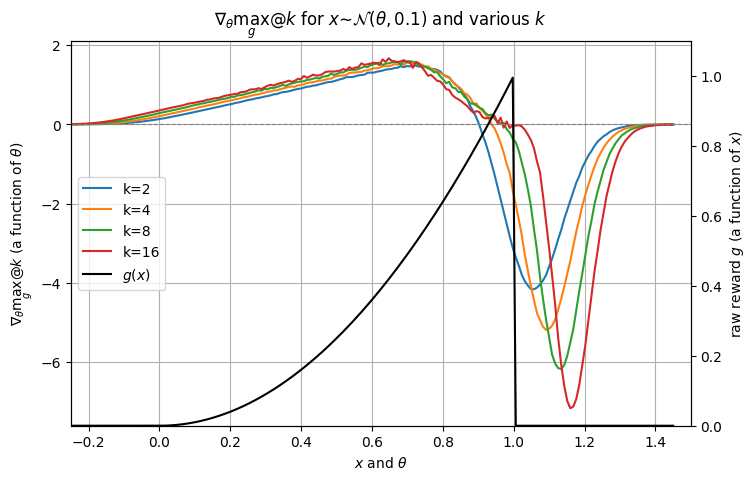

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the raw reward function g(x)
def g(x):
    # g(x) = x^2 for 0 <= x <= 1, else 0
    return np.where((x >= 0) & (x <= 1), x**2, 0.0)

# Setup parameters
thetas = np.linspace(-0.25, 1.45, 200)
ks = [2, 4, 8, 16]
sigma = 0.1
N = 500000  # High MC sample count for exact/smooth curves

fig, ax1 = plt.subplots(figsize=(8, 5))

# Use a fixed random seed for reproducibility
np.random.seed(42)

# 2. Estimate the expected gradient for each k and theta
for k in ks:
    grads = []
    for theta in thetas:
        # Sample Z ~ N(0, 1) and reparameterize to X ~ N(theta, sigma^2)
        Z = np.random.randn(N, k)
        X = theta + sigma * Z
        
        # Calculate rewards and find the maximum over the k samples
        G = g(X)
        max_G = np.max(G, axis=1) # shape (N,)
        
        # REINFORCE score function: sum_i (x_i - theta) / sigma^2 = sum_i z_i / sigma
        score = np.sum(Z / sigma, axis=1)
        
        # The expected gradient is the mean of the reward * score
        grad = np.mean(max_G * score)
        grads.append(grad)
        
    # Plot the gradient curve for this k
    ax1.plot(thetas, grads, label=f'k={k}')

# 3. Format the primary axes (Gradient of max_g@k)
ax1.set_xlabel(r'$x$ and $\theta$')
ax1.set_ylabel(r'$\nabla_\theta \max_g @ k$ (a function of $\theta$)')
ax1.set_xlim([-0.25, 1.5])
ax1.grid(True)
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# 4. Add the secondary axes for the raw reward g(x)
ax2 = ax1.twinx()
ax2.plot(thetas, g(thetas), 'k-', label=r'$g(x)$')
ax2.set_ylabel(r'raw reward $g$ (a function of $x$)')
ax2.set_ylim([0, 1.1])

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center left')

plt.title(r'$\nabla_\theta \max_g @ k$ for $x \sim \mathcal{N}(\theta, 0.1)$ and various $k$')
plt.savefig('figure_1b.png', bbox_inches='tight')

Running all-subsets methods...


Running partitioned methods...


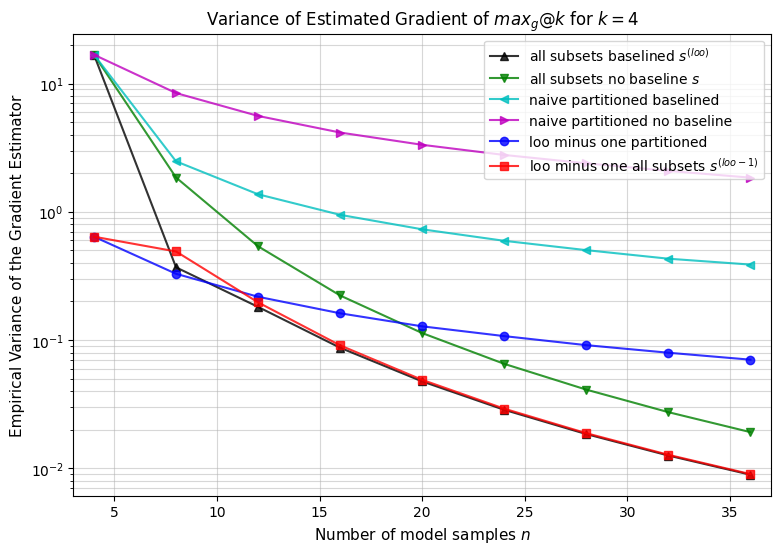

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import comb

# --- Core Estimator Logic ---

def max_g_at_k(g_sorted, k):
    """Expected maximum reward drawing k items from sorted array."""
    if k == 0: return 0.0
    n = len(g_sorted)
    if n < k: return 0.0
    i_idx = np.arange(k - 1, n)
    return np.mean(comb(i_idx, k - 1) * g_sorted[i_idx]) / comb(n, k)

def get_s_unbiased_vec(g_array, k):
    """Computes the unbiased estimator 's' (Eq 19) for all items."""
    n = len(g_array)
    sort_idx = np.argsort(g_array)
    g_sorted = g_array[sort_idx]
    
    s_sorted = np.zeros(n)
    denom = comb(n, k)
    
    # Diagonals (when the item itself is the maximum of the k subset)
    i_diag = np.arange(k - 1, n)
    s_sorted[i_diag] += comb(i_diag, k - 1) * g_sorted[i_diag]
    
    # Off-diagonals (when a larger item j is the maximum)
    j_idx = np.arange(k - 1, n)
    terms = comb(j_idx - 1, k - 2) * g_sorted[j_idx] if k >= 2 else np.zeros_like(j_idx)
    
    all_terms = np.zeros(n)
    all_terms[j_idx] = terms
    suffix_sums = np.cumsum(all_terms[::-1])[::-1]
    
    i_off = np.arange(n - 1)
    s_sorted[i_off] += suffix_sums[i_off + 1]
    
    s_sorted /= denom
    
    # Restore original ordering
    s_out = np.zeros(n)
    s_out[sort_idx] = s_sorted
    return s_out

def get_s_loo_vec(g_array, k):
    """Computes 's_loo' (Eq 29) using Leave-One-Out subset baseline."""
    n = len(g_array)
    s_unb = get_s_unbiased_vec(g_array, k)
    s_out = np.zeros(n)
    for i in range(n):
        g_minus = np.delete(g_array, i)
        # Expected max of k draws from the (N-1) items excluding item i
        s_out[i] = s_unb[i] - max_g_at_k(np.sort(g_minus), k)
    return s_out

def get_s_loo_minus_one_vec(g_array, k):
    """Computes 's_loo_minus_one' (Eq 33) baseline using (k-1) subsets."""
    n = len(g_array)
    s_unb = get_s_unbiased_vec(g_array, k)
    s_out = np.zeros(n)
    for i in range(n):
        g_minus = np.delete(g_array, i)
        g_sorted = np.sort(g_minus)
        # Partition the baseline into subsets that would contain i vs subsets that wouldn't
        term1 = (k / n) * max_g_at_k(g_sorted, k - 1)
        term2 = ((n - k) / n) * max_g_at_k(g_sorted, k)
        s_out[i] = s_unb[i] - (term1 + term2)
    return s_out

# --- Partitioned Baselines ---

def get_part_naive_base(g_array, k):
    n = len(g_array)
    s_out = np.zeros(n)
    nb = n // k
    block_maxes = [np.max(g_array[b*k:(b+1)*k]) for b in range(nb)]
    for b in range(nb):
        Mb = block_maxes[b]
        baseline = (sum(block_maxes) - Mb) / (nb - 1) if nb > 1 else 0.0
        s_out[b*k:(b+1)*k] = Mb - baseline
    return s_out

def get_part_naive_nobase(g_array, k):
    n = len(g_array)
    s_out = np.zeros(n)
    for b in range(n // k):
        s_out[b*k:(b+1)*k] = np.max(g_array[b*k:(b+1)*k])
    return s_out

def get_part_loo_minus_one(g_array, k):
    n = len(g_array)
    s_out = np.zeros(n)
    for b in range(n // k):
        s_out[b*k:(b+1)*k] = get_s_loo_minus_one_vec(g_array[b*k:(b+1)*k], k)
    return s_out


# --- Run 10,000 Monte Carlo Simulation Trials ---

np.random.seed(42)
theta = 1.0     # Mean evaluation location
sigma = 0.1     # Standard deviation of policy
k = 4
n_trials = 10000

# To map the continuous lines correctly vs partitioned jumps
ns_all = np.arange(4, 37, 4)
ns_part = np.arange(4, 37, 4)

var_s = []
var_s_loo = []
var_s_loo_min = []
var_p_base = []
var_p_nobase = []
var_p_loo_min = []

# Generate all stochastic variables upfront
Z_all = np.random.randn(n_trials, max(ns_all))
X_all = theta + sigma * Z_all
# g(x) = x^2 for 0 <= x <= 1, else 0
G_all = np.where((X_all >= 0) & (X_all <= 1), X_all**2, 0.0)
# Score function gradient: Z / sigma
Grad_log_p_all = Z_all / sigma

print("Running all-subsets methods...")
for n in ns_all:
    grads_s = np.zeros(n_trials)
    grads_s_loo = np.zeros(n_trials)
    grads_s_loo_min = np.zeros(n_trials)
    for t in range(n_trials):
        gt = G_all[t, :n]
        dlogp = Grad_log_p_all[t, :n]
        
        # Accumulate the sum of (transformed_reward * gradient_score)
        grads_s[t] = np.mean(get_s_unbiased_vec(gt, k) * dlogp)
        grads_s_loo[t] = np.mean(get_s_loo_vec(gt, k) * dlogp)
        grads_s_loo_min[t] = np.mean(get_s_loo_minus_one_vec(gt, k) * dlogp)
        
    # Store the variance of the gradients across the 10,000 samples
    var_s.append(np.var(grads_s))
    var_s_loo.append(np.var(grads_s_loo))
    var_s_loo_min.append(np.var(grads_s_loo_min))

print("Running partitioned methods...")
for n in ns_part:
    grads_p_base = np.zeros(n_trials)
    grads_p_nobase = np.zeros(n_trials)
    grads_p_loo_min = np.zeros(n_trials)
    for t in range(n_trials):
        gt = G_all[t, :n]
        dlogp = Grad_log_p_all[t, :n]
        
        grads_p_base[t] = np.mean(get_part_naive_base(gt, k) * dlogp)
        grads_p_nobase[t] = np.mean(get_part_naive_nobase(gt, k) * dlogp)
        grads_p_loo_min[t] = np.mean(get_part_loo_minus_one(gt, k) * dlogp)
        
    var_p_base.append(np.var(grads_p_base))
    var_p_nobase.append(np.var(grads_p_nobase))
    var_p_loo_min.append(np.var(grads_p_loo_min))

# --- Formatting the final figure ---
plt.figure(figsize=(9, 6))

plt.plot(ns_all, var_s_loo, '^-k', markersize=6, alpha=0.8, label=r'all subsets baselined $s^{(loo)}$')
plt.plot(ns_all, var_s, 'v-g', markersize=6, alpha=0.8, label=r'all subsets no baseline $s$')
plt.plot(ns_part, var_p_base, '<-c', markersize=6, alpha=0.8, label='naive partitioned baselined')
plt.plot(ns_part, var_p_nobase, '>-m', markersize=6, alpha=0.8, label='naive partitioned no baseline')
plt.plot(ns_part, var_p_loo_min, 'o-b', markersize=6, alpha=0.8, label='loo minus one partitioned')
plt.plot(ns_all, var_s_loo_min, 's-r', markersize=6, alpha=0.8, label=r'loo minus one all subsets $s^{(loo-1)}$')

plt.yscale('log')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Number of model samples $n$', fontsize=11)
plt.ylabel('Empirical Variance of the Gradient Estimator', fontsize=11)
plt.title(r'Variance of Estimated Gradient of $max_g@k$ for $k=4$', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.xlim([3, 37])
plt.savefig('figure_4.png', bbox_inches='tight')
plt.show()